Improper waste segregation is a major environmental challenge that leads to increased landfill pollution and inefficient recycling processes. Manual sorting of waste is time-consuming, inconsistent, and not scalable in real-world scenarios.

The objective of this project is to develop an image classification system for waste segregation using deep learning. A pre-trained convolutional neural network (EfficientNetB0) is used as a feature extractor and fine-tuned on the TrashNet dataset, which contains six classes of waste: cardboard, glass, metal, paper, plastic, and trash.

The model is trained using transfer learning techniques to achieve high classification accuracy while reducing training time and computational cost. Data augmentation is applied to improve generalization, and performance is evaluated using accuracy, precision, recall, F1-score, and confusion matrix.

The final goal is to build an efficient and reliable system that can automatically classify waste images, supporting smart waste management and environmental sustainability initiatives.

Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Set Dataset Path

In [2]:
import os

train_dir = "/content/drive/MyDrive/data/trashnet"

print(os.listdir(train_dir))  # must show 6 folders

['trash', 'glass', 'cardboard', 'metal', 'plastic', 'paper']


Import Libraries

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

Load Dataset

In [4]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="training",
    seed=123,
    label_mode="int"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="validation",
    seed=123,
    label_mode="int"
)

class_names = train_ds.class_names
print(class_names)

Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.
['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


Optimize Dataset

In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Data Augmentation

In [6]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

Load EfficientNetB0

In [7]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Build Model

In [8]:
inputs = keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

# IMPORTANT: EfficientNet preprocessing
x = tf.keras.applications.efficientnet.preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(6, activation="softmax")(x)

model = keras.Model(inputs, outputs)

Compile Model

In [9]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Callbacks

In [10]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-6
    )
]

Train Model

In [11]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 353s 1s/step - accuracy: 0.6469 - loss: 1.0075 - val_accuracy: 0.7842 - val_loss: 0.6556 - learning_rate: 0.0010
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - accuracy: 0.7864 - loss: 0.6156 - val_accuracy: 0.8297 - val_loss: 0.5158 - learning_rate: 0.0010
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - accuracy: 0.8215 - loss: 0.5252 - val_accuracy: 0.8475 - val_loss: 0.4576 - learning_rate: 0.0010
Epoch 4/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - accuracy: 0.8467 - loss: 0.4580 - val_accuracy: 0.8673 - val_loss: 0.4247 - learning_rate: 0.0010
Epoch 5/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - accuracy: 0.8684 - loss: 0.4025 - val_accuracy: 0.8634 - val_loss: 0.3955 - learning_rate: 0.0010
Epoch 6/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - accuracy: 0.8650 - loss: 0.3976 - val_accuracy: 0.8693 - val_loss: 0.3776 - learning_rate: 0.0010
Epoch 7/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - accuracy: 0.8704 - loss: 0.3750 - val_acc

Evaluate Model

In [12]:
loss, acc = model.evaluate(val_ds)
print("Validation Accuracy:", acc)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.8832 - loss: 0.3360
Validation Accuracy: 0.8831683397293091


Plot Accuracy/Loss

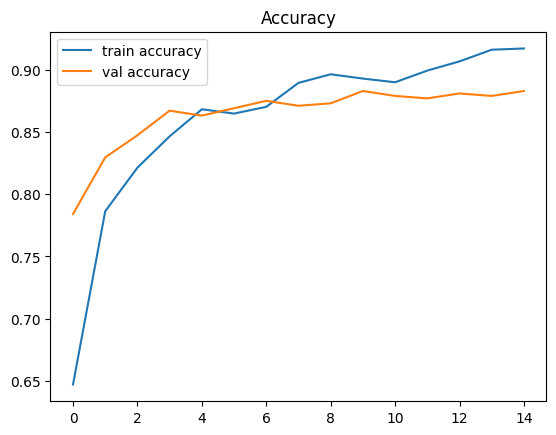

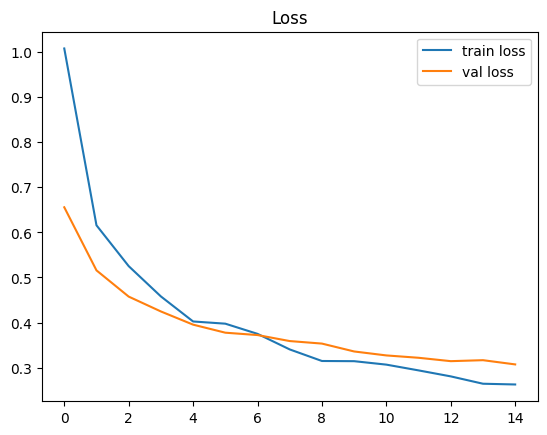

In [13]:
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss")
plt.show()

Classification Report

In [14]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

   cardboard       0.93      0.89      0.91        83
       glass       0.85      0.93      0.89       103
       metal       0.91      0.90      0.90        78
       paper       0.86      0.93      0.89       124
     plastic       0.91      0.81      0.86        88
       trash       0.83      0.69      0.75        29

    accuracy                           0.88       505
   macro avg       0.88      0.86      0.87       505
weighted avg       0.88      0.88      0.88       505



Confusion Matrix

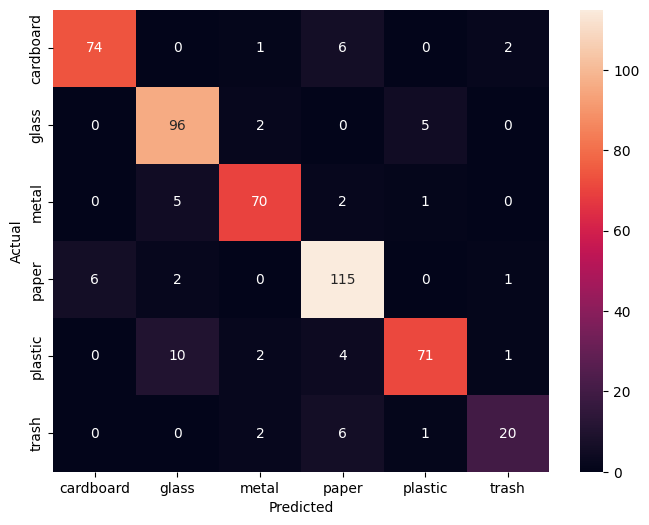

In [15]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Save Model

In [16]:
model.save("/content/drive/MyDrive/trashnet_model.h5")

Final Result & Conclusion — TrashNet Classification

The trained EfficientNetB0-based transfer learning model was evaluated on the TrashNet validation dataset containing six waste categories: cardboard, glass, metal, paper, plastic, and trash.

The model achieved the following performance:

Validation Accuracy: 88.32%
Validation Loss: 0.3360

These results indicate that the model has learned meaningful visual features for waste classification and performs well on unseen data.

Class-wise evaluation shows that most categories such as cardboard, paper, glass, and metal are classified with high precision and recall. However, the trash class shows comparatively lower performance, mainly due to fewer training samples and higher visual variability.

Overall, the model demonstrates strong generalization ability using transfer learning with EfficientNetB0 and data augmentation. This system can be further improved using fine-tuning, class balancing, and additional dataset augmentation.

This project successfully demonstrates a deep learning-based approach for automated waste classification, contributing toward smart waste management and environmental sustainability.